In [1]:
%pip install ultralytics roboflow -q
import ultralytics
import os
import shutil
import glob
import yaml
import cv2
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
from ultralytics import YOLO
from roboflow import Roboflow

# 1. CONFIGURATION
WORKING_DIR = '/kaggle/working/vehicle_project'
MODEL_TYPE = 'yolo11n.pt'  # Changed to nano

# UNIFIED CLASS LIST
# 0: car, 1: bus, 2: truck, 3: motorcycle, 4: van, 5: threewheel
CLASSES = {
    0: 'car', 
    1: 'bus', 
    2: 'truck', 
    3: 'motorcycle', 
    4: 'van', 
    5: 'threewheel'
}

Note: you may need to restart the kernel to use updated packages.


In [2]:
# TEMP: Inspect Dataset 3 labels to figure out real class IDs
import random
label_files = glob.glob("/kaggle/working/raw_ds_2/train/labels/*.txt")
sample = random.sample(label_files, min(10, len(label_files)))
for lf in sample:
    with open(lf) as f:
        lines = f.readlines()
    class_ids = set(int(l.split()[0]) for l in lines if l.strip())
    print(f"{os.path.basename(lf)}: classes used = {class_ids}")

tyoto_minivan2062_png.rf.a4ff857d66cc43c4f996a05bd4120180.txt: classes used = {21}
WhatsApp-Image-2022-11-29-at-20-15-44-1-_jpeg_jpg.rf.15d98fbe8a985778d6430376b1284552.txt: classes used = {23}
WhatsApp-Image-2022-12-05-at-18-17-30_jpeg_jpg.rf.7e809c7d68cac097f50a18f71200e246.txt: classes used = {22}
img-00351_jpg.rf.de14c0df0887640ab55bc59ecae1dab1.txt: classes used = {5, 6, 7, 8, 9, 10, 11, 12}
20230222_174318_jpg.rf.90f8666dd353150285fb3bbf6f3a34aa.txt: classes used = {6}
0502_jpg.rf.25ef10c1915d7254848880c71e19cf2b.txt: classes used = {25}
-B41BBCCE-A512-4CBA-94C0-D236EC1DEBA1-png_jpg.rf.3126a5363139cfddd9ab836b37551902.txt: classes used = {22}
370_jpg.rf.59e4e2710bd9a64abced670d1bb236f5.txt: classes used = {26}
IMG_20250325_113258_jpg.rf.31338b54d809d1cce37f7767ac06b535.txt: classes used = {21}
0563_jpg.rf.370a67fe862aba3cf9ee67ca8ca1d184.txt: classes used = {25}


In [3]:
# TEMP: Read raw yaml file of dataset 3
with open("/kaggle/working/raw_ds_2/data.yaml") as f:
    content = f.read()
print(content)

names:
- '-'
- '- annotate- and create datasets'
- '- collaborate with your team on computer vision projects'
- '- collect - organize images'
- '- understand and search unstructured image data'
- '0'
- '1'
- '2'
- '3'
- '4'
- '5'
- '6'
- '7'
- Roboflow is an end-to-end computer vision platform that helps you
- This dataset was exported via roboflow.com on October 16- 2023 at 11-28 AM GMT
- bus
- bus_07
- bus_27
- bus_46
- bus_55A
- bus_55B
- car
- car_models - v1 2023-10-05 3-03pm
- cars
- empty road
- motorbike
- motorcycle
- truck
- van
- vehicle
nc: 30
roboflow:
  license: CC BY 4.0
  project: vehicles-jrny7
  url: https://universe.roboflow.com/codee-p31ru/vehicles-jrny7/dataset/1
  version: 1
  workspace: codee-p31ru
test: ../test/images
train: ../train/images
val: ../valid/images



In [4]:
# 2. DOWNLOAD & MERGE DATASETS

print("Downloading and merging 3 Roboflow datasets...")

if os.path.exists(WORKING_DIR):
    shutil.rmtree(WORKING_DIR)
os.makedirs(WORKING_DIR)

rf = Roboflow(api_key="yoDD8EsZDtmxJZTG5kMB")

DATASETS = [
    ("pbl6-iwdrc",                                         "vehicle-model-kp6ub",  1),
    ("faculty-of-engineering-alexandria-university-mvdnh", "vehicles-sgibq",       1),
    ("codee-p31ru",                                        "vehicles-jrny7",       1),
]

# Unified: 0=car, 1=bus, 2=truck, 3=motorcycle, 4=van, 5=threewheel
REMAPS = [
    # Dataset 1: ['car'=0, 'motorcycle'=1]
    {0: 0, 1: 3},

    # Dataset 2: ['bus'=0, 'car'=1, 'motorbike'=2, 'threewheel'=3, 'truck'=4, 'van'=5]
    {0: 1, 1: 0, 2: 3, 3: 5, 4: 2, 5: 4},

    # Dataset 3: corrupted yaml — mapping valid vehicle classes only, rest discarded
    # 15=bus, 16=bus_07, 17=bus_27, 18=bus_46, 19=bus_55A, 20=bus_55B → all bus variants → 1
    # 21=car, 22=car_models(junk), 23=cars → car → 0
    # 25=motorbike, 26=motorcycle → motorcycle → 3
    # 27=truck → 2
    # 28=van → 4
    # everything else (0-14, 22, 24, 29) = junk/noise → discarded (not in remap)
    {15: 1, 16: 1, 17: 1, 18: 1, 19: 1, 20: 1,
     21: 0, 23: 0,
     25: 3, 26: 3,
     27: 2,
     28: 4},
]

def merge_split(src_dir, split, remap):
    src_images = os.path.join(src_dir, split, 'images')
    src_labels = os.path.join(src_dir, split, 'labels')
    dst_images = os.path.join(WORKING_DIR, split, 'images')
    dst_labels = os.path.join(WORKING_DIR, split, 'labels')
    os.makedirs(dst_images, exist_ok=True)
    os.makedirs(dst_labels, exist_ok=True)

    if not os.path.exists(src_images):
        print(f"   WARNING: {src_images} not found, skipping.")
        return 0

    count = 0
    for img_file in glob.glob(f"{src_images}/*.jpg") + glob.glob(f"{src_images}/*.png"):
        basename = os.path.splitext(os.path.basename(img_file))[0]
        label_file = os.path.join(src_labels, basename + '.txt')

        if not os.path.exists(label_file):
            continue

        with open(label_file, 'r') as f:
            lines = f.readlines()

        new_lines = []
        for line in lines:
            parts = line.strip().split()
            if len(parts) > 0:
                old_id = int(parts[0])
                new_id = remap.get(old_id, None)
                if new_id is not None:
                    parts[0] = str(new_id)
                    new_lines.append(' '.join(parts) + '\n')

        # Only copy image if it has at least one valid label after remapping
        if new_lines:
            shutil.copy(img_file, os.path.join(dst_images, os.path.basename(img_file)))
            with open(os.path.join(dst_labels, basename + '.txt'), 'w') as f:
                f.writelines(new_lines)
            count += 1

    return count

total = 0
for i, (workspace, project_name, version) in enumerate(DATASETS):
    print(f"\nDownloading dataset {i+1}/3: {project_name}...")
    project = rf.workspace(workspace).project(project_name)
    dataset = project.version(version).download("yolov8", location=f"/kaggle/working/raw_ds_{i}")

    print(f"   Merging dataset {i+1}...")
    for split in ['train', 'valid', 'test']:
        n = merge_split(f"/kaggle/working/raw_ds_{i}", split, REMAPS[i])
        total += n
        print(f"   -> {split}: {n} images merged")

print(f"\nTotal images merged into {WORKING_DIR}: {total}")


loading Roboflow workspace...
loading Roboflow project...
   Merging dataset 1...
   -> train: 7829 images merged
   -> valid: 0 images merged
   -> test: 0 images merged

loading Roboflow workspace...
loading Roboflow project...
   Merging dataset 2...
   -> train: 2040 images merged
   -> valid: 897 images merged
   -> test: 0 images merged

loading Roboflow workspace...
loading Roboflow project...
   Merging dataset 3...
   -> train: 2777 images merged
   -> valid: 320 images merged
   -> test: 132 images merged

Total images merged into /kaggle/working/vehicle_project: 13995


In [5]:
# 3. SMART DATA CLEANING

print("Cleaning Data (Removing Rotations & Errors)...")

all_images = glob.glob(f"{WORKING_DIR}/**/*.jpg", recursive=True)
all_labels = glob.glob(f"{WORKING_DIR}/**/*.txt", recursive=True)

# A. ROTATION DEDUPLICATOR
unique_scenes = set()
deleted_rotations = 0

for img_path in tqdm(all_images, desc="Removing Rotated Duplicates"):
    filename = os.path.basename(img_path)
    
    if "_jpg.rf." in filename:
        core_name = filename.split("_jpg.rf.")[0]
    else:
        core_name = filename 
        
    if core_name in unique_scenes:
        try:
            os.remove(img_path)
            label_path = img_path.replace('/images/', '/labels/').replace('.jpg', '.txt')
            if os.path.exists(label_path):
                os.remove(label_path)
            deleted_rotations += 1
        except OSError:
            pass
    else:
        unique_scenes.add(core_name)

print(f"   -> Deleted {deleted_rotations} rotated duplicate images.")

# B. LABEL SCRUBBER
cleaned_labels = 0
for label_file in tqdm(all_labels, desc="Verifying Labels"):
    try:
        with open(label_file, 'r') as f:
            lines = f.readlines()
        
        new_lines = []
        modified = False
        for line in lines:
            parts = line.strip().split()
            if len(parts) > 0:
                cls_id = int(parts[0])
                if cls_id <= 5:
                    new_lines.append(line)
                else:
                    modified = True
        
        if modified:
            with open(label_file, 'w') as f:
                f.writelines(new_lines)
            cleaned_labels += 1
    except Exception:
        continue

print(f"   -> Scrubbed {cleaned_labels} files with invalid class IDs (>5).")

Cleaning Data (Removing Rotations & Errors)...


Removing Rotated Duplicates:   0%|          | 0/13995 [00:00<?, ?it/s]

   -> Deleted 3823 rotated duplicate images.


Verifying Labels:   0%|          | 0/13995 [00:00<?, ?it/s]

   -> Scrubbed 0 files with invalid class IDs (>5).


In [6]:
# 4. CONFIG GENERATION
print("Generating Correct data.yaml...")
yaml_data = {
    'path': WORKING_DIR,
    'train': 'train/images',
    'val': 'valid/images',
    'test': 'test/images',
    'nc': len(CLASSES),
    'names': list(CLASSES.values())
}
with open(f'{WORKING_DIR}/data.yaml', 'w') as f:
    yaml.dump(yaml_data, f)

Generating Correct data.yaml...


In [7]:
# 5. TRAINING
print("Starting Training...")
model = YOLO(MODEL_TYPE)

results = model.train(
    data=f'{WORKING_DIR}/data.yaml',
    epochs=50,
    imgsz=640,
    batch=-1,          # auto batch
    patience=15,       # slightly more patience for a harder merged dataset
    optimizer='AdamW', # better than default SGD for mixed/noisy datasets
    lr0=0.001,         # good starting LR for AdamW
    augment=True,      # extra augmentation helps with dataset variety
    mosaic=1.0,        # mosaic augmentation — great for multi-dataset training
    mixup=0.1,         # light mixup helps generalization
    cos_lr=True,       # cosine LR schedule — smoother convergence
    project='vehicle_project',
    name='final_model_v1',
    exist_ok=True,
    verbose=False,
    plots=True
)

Starting Training...
Ultralytics 8.4.21 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=True, auto_augment=randaugment, batch=-1, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/kaggle/working/vehicle_project/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.1, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=final_model_v1, nbs=64, nms=False, opset=None, optimize=False, optimizer=AdamW, over

In [9]:
# 6. EXPORT (FIXED)
print("Zipping Results...")

ACTUAL_RESULTS_DIR = '/kaggle/working/runs/detect/vehicle_project/final_model_v1'

model.export(format='onnx')
shutil.make_archive('/kaggle/working/final_results', 'zip', ACTUAL_RESULTS_DIR)
print("Download 'final_results.zip' from Output tab.")

Zipping Results...
Ultralytics 8.4.21 🚀 Python-3.12.12 torch-2.9.0+cu126 CPU (Intel Xeon CPU @ 2.00GHz)
YOLO11n summary (fused): 101 layers, 2,583,322 parameters, 0 gradients, 6.3 GFLOPs

PyTorch: starting from '/kaggle/working/runs/detect/vehicle_project/final_model_v1/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 10, 8400) (5.2 MB)

ONNX: starting export with onnx 1.20.1 opset 22...
ONNX: slimming with onnxslim 0.1.87...
ONNX: export success ✅ 1.4s, saved as '/kaggle/working/runs/detect/vehicle_project/final_model_v1/weights/best.onnx' (10.1 MB)

Export complete (1.8s)
Results saved to /kaggle/working/runs/detect/vehicle_project/final_model_v1/weights
Predict:         yolo predict task=detect model=/kaggle/working/runs/detect/vehicle_project/final_model_v1/weights/best.onnx imgsz=640 
Validate:        yolo val task=detect model=/kaggle/working/runs/detect/vehicle_project/final_model_v1/weights/best.onnx imgsz=640 data=/kaggle/working/vehicle_project/

In [11]:
found_plots = glob.glob("/kaggle/working/runs/**/*.png", recursive=True)
for f in found_plots:
    print(f)

/kaggle/working/runs/detect/vehicle_project/final_model_v1/BoxF1_curve.png
/kaggle/working/runs/detect/vehicle_project/final_model_v1/BoxPR_curve.png
/kaggle/working/runs/detect/vehicle_project/final_model_v1/BoxP_curve.png
/kaggle/working/runs/detect/vehicle_project/final_model_v1/confusion_matrix_normalized.png
/kaggle/working/runs/detect/vehicle_project/final_model_v1/results.png
/kaggle/working/runs/detect/vehicle_project/final_model_v1/confusion_matrix.png
/kaggle/working/runs/detect/vehicle_project/final_model_v1/BoxR_curve.png


FOUND MODEL AT: /kaggle/working/runs/detect/vehicle_project/final_model_v1/weights/best.pt
Copied to /kaggle/working/best.pt (Download this file!)

📊 CONFUSION MATRIX:


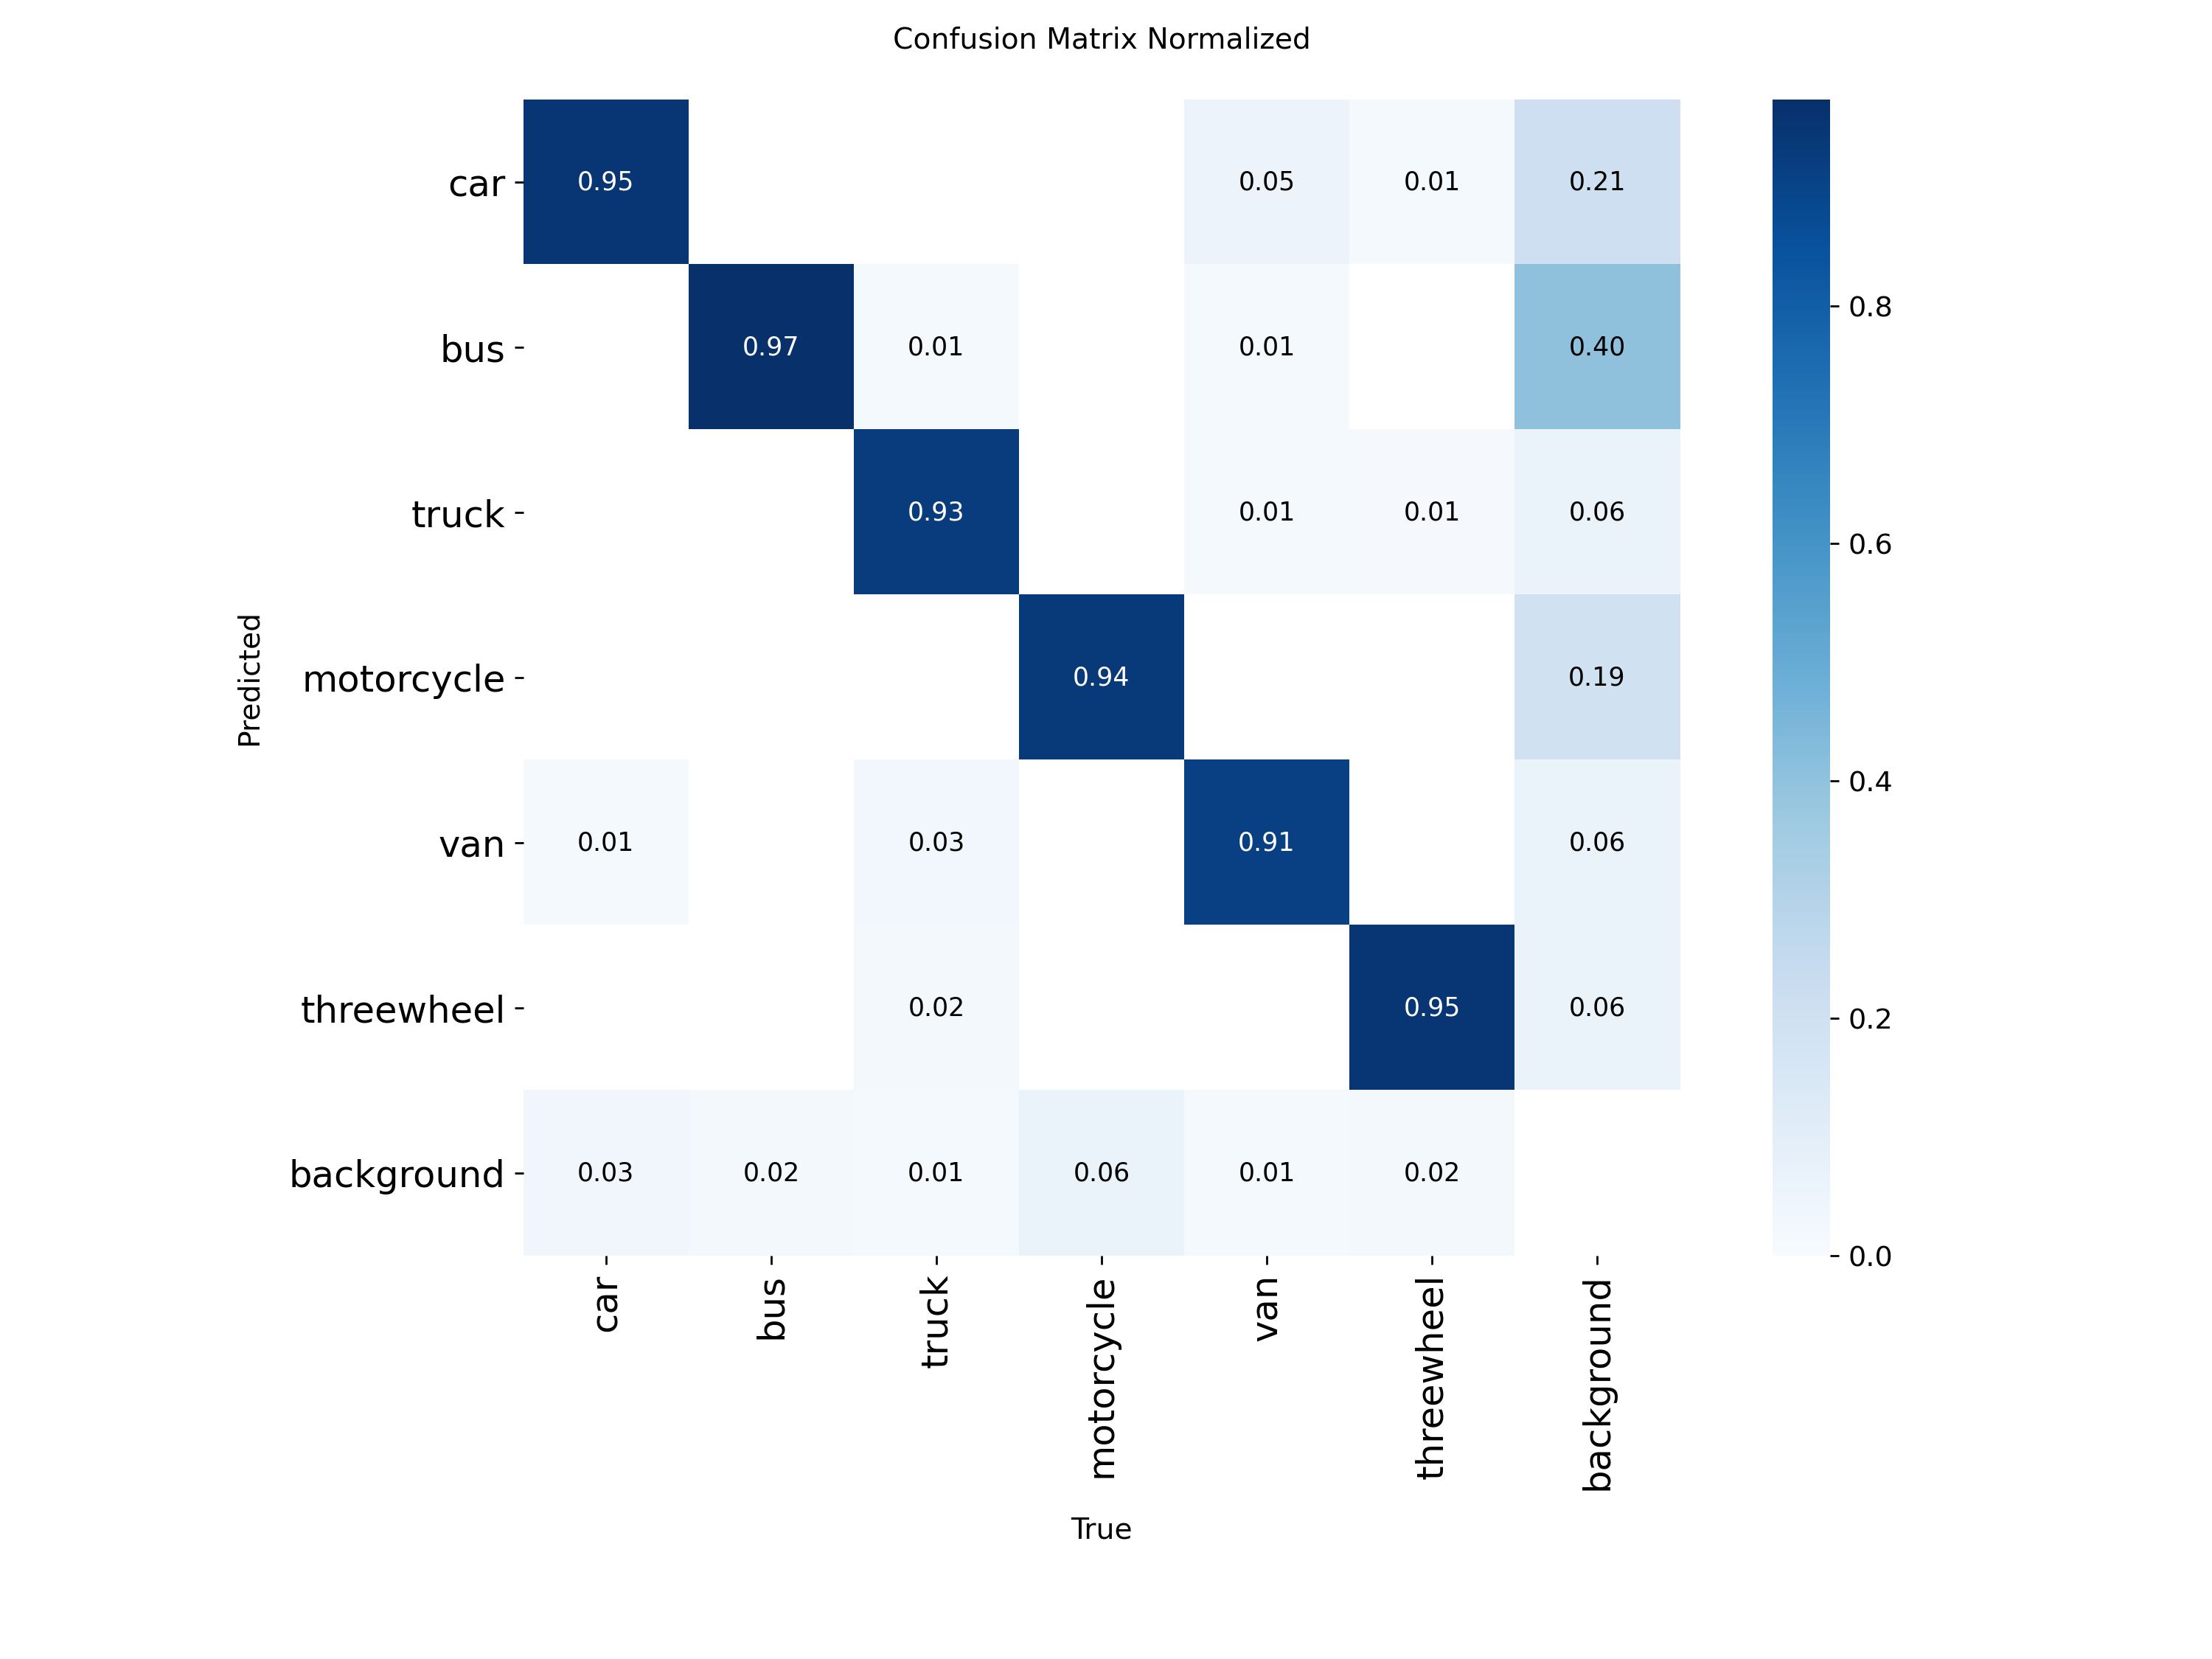


📈 TRAINING CURVES:


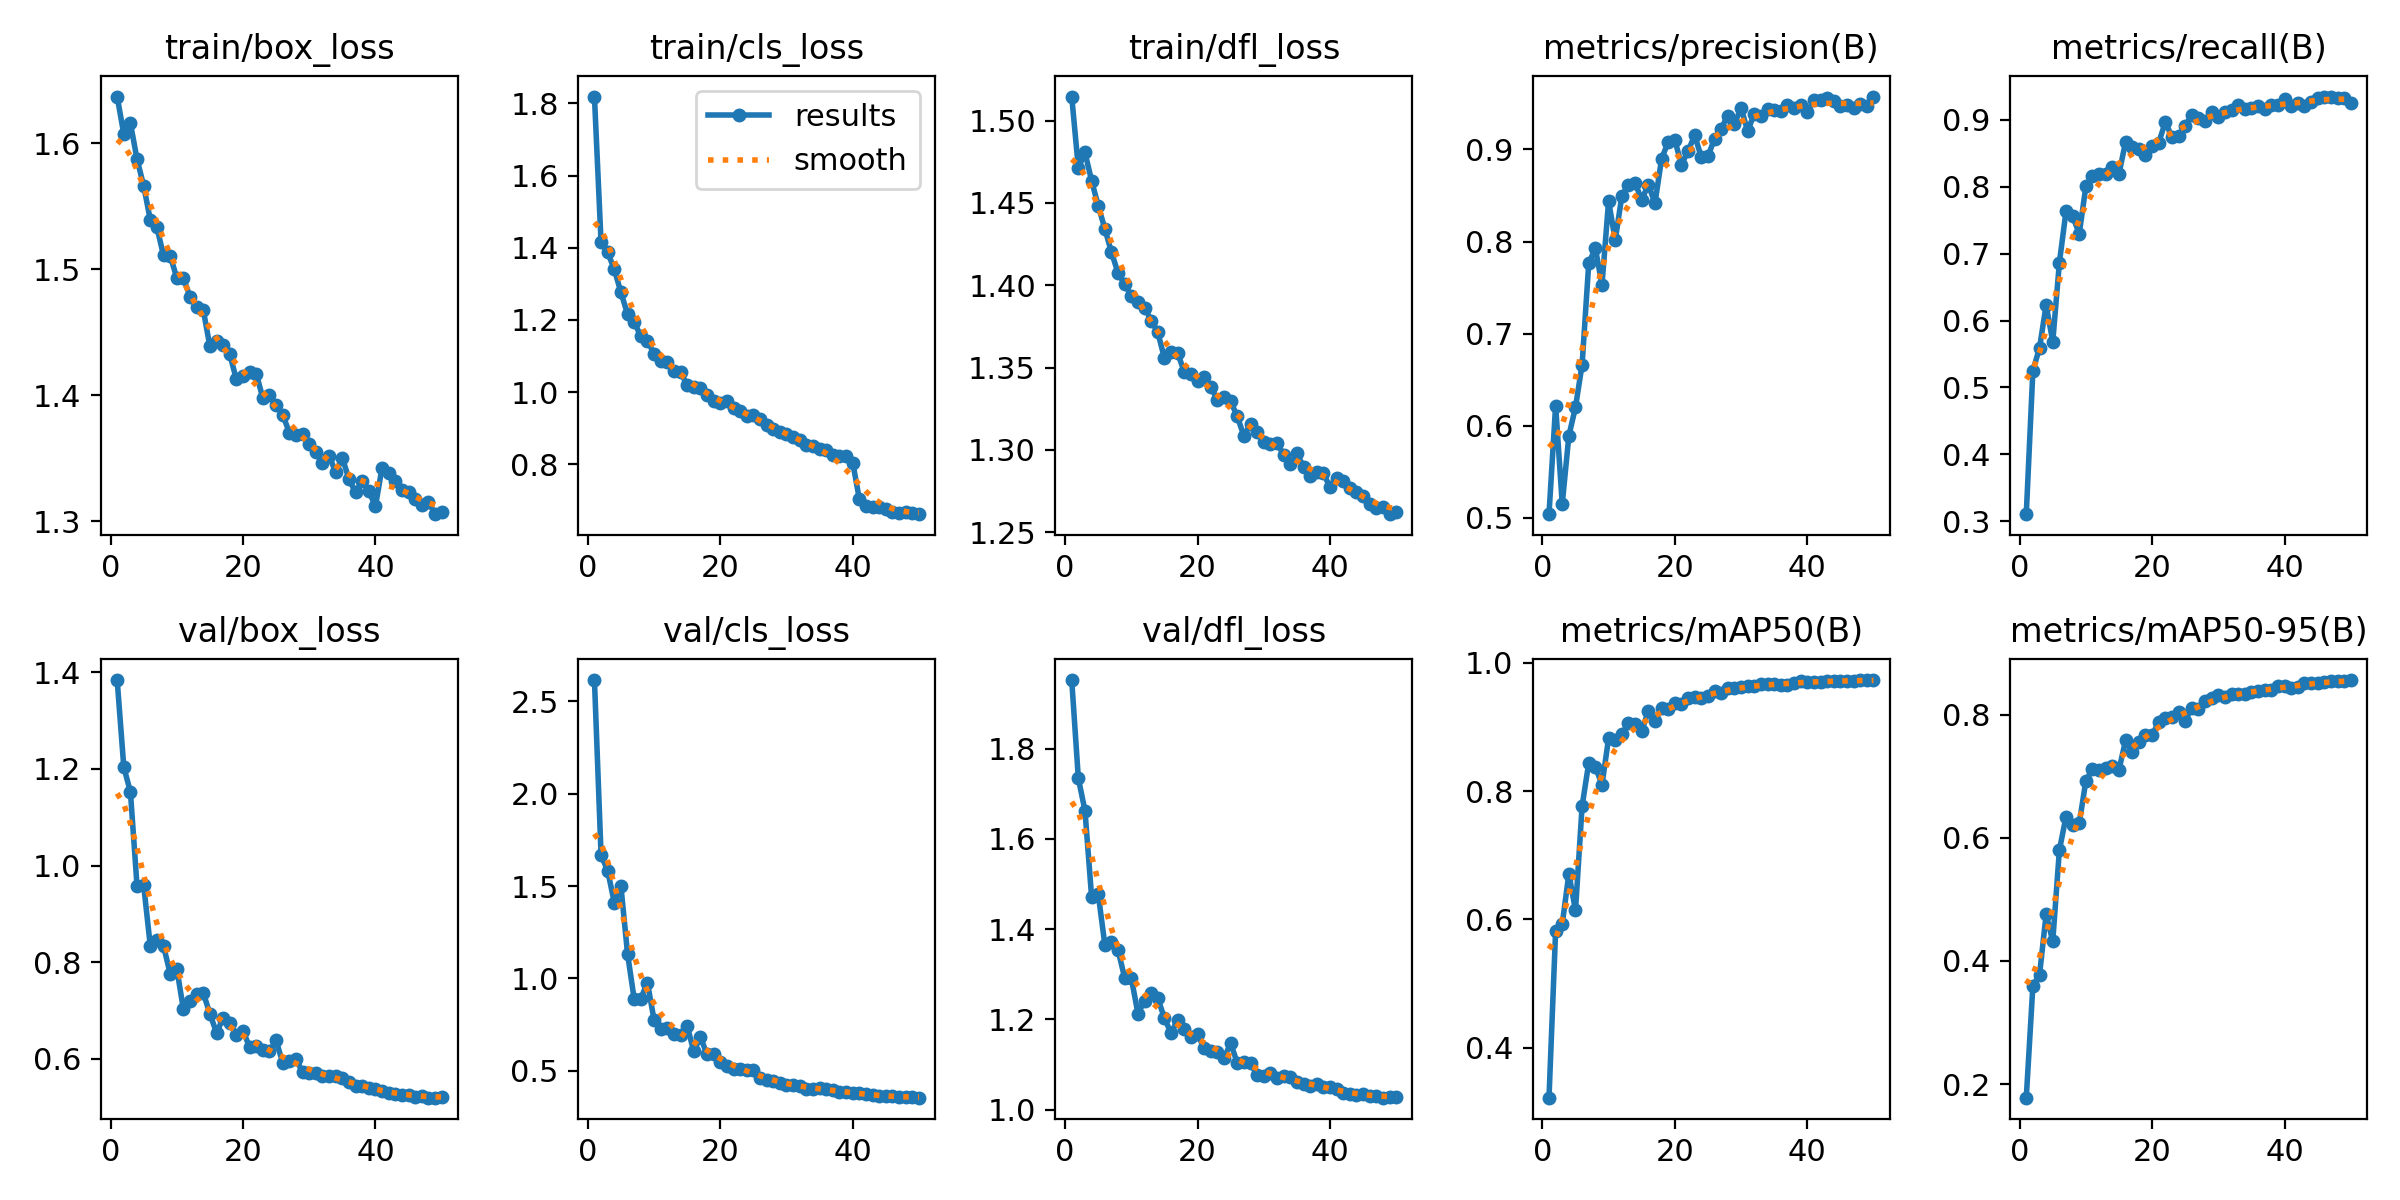


🎯 PRECISION-RECALL CURVE:


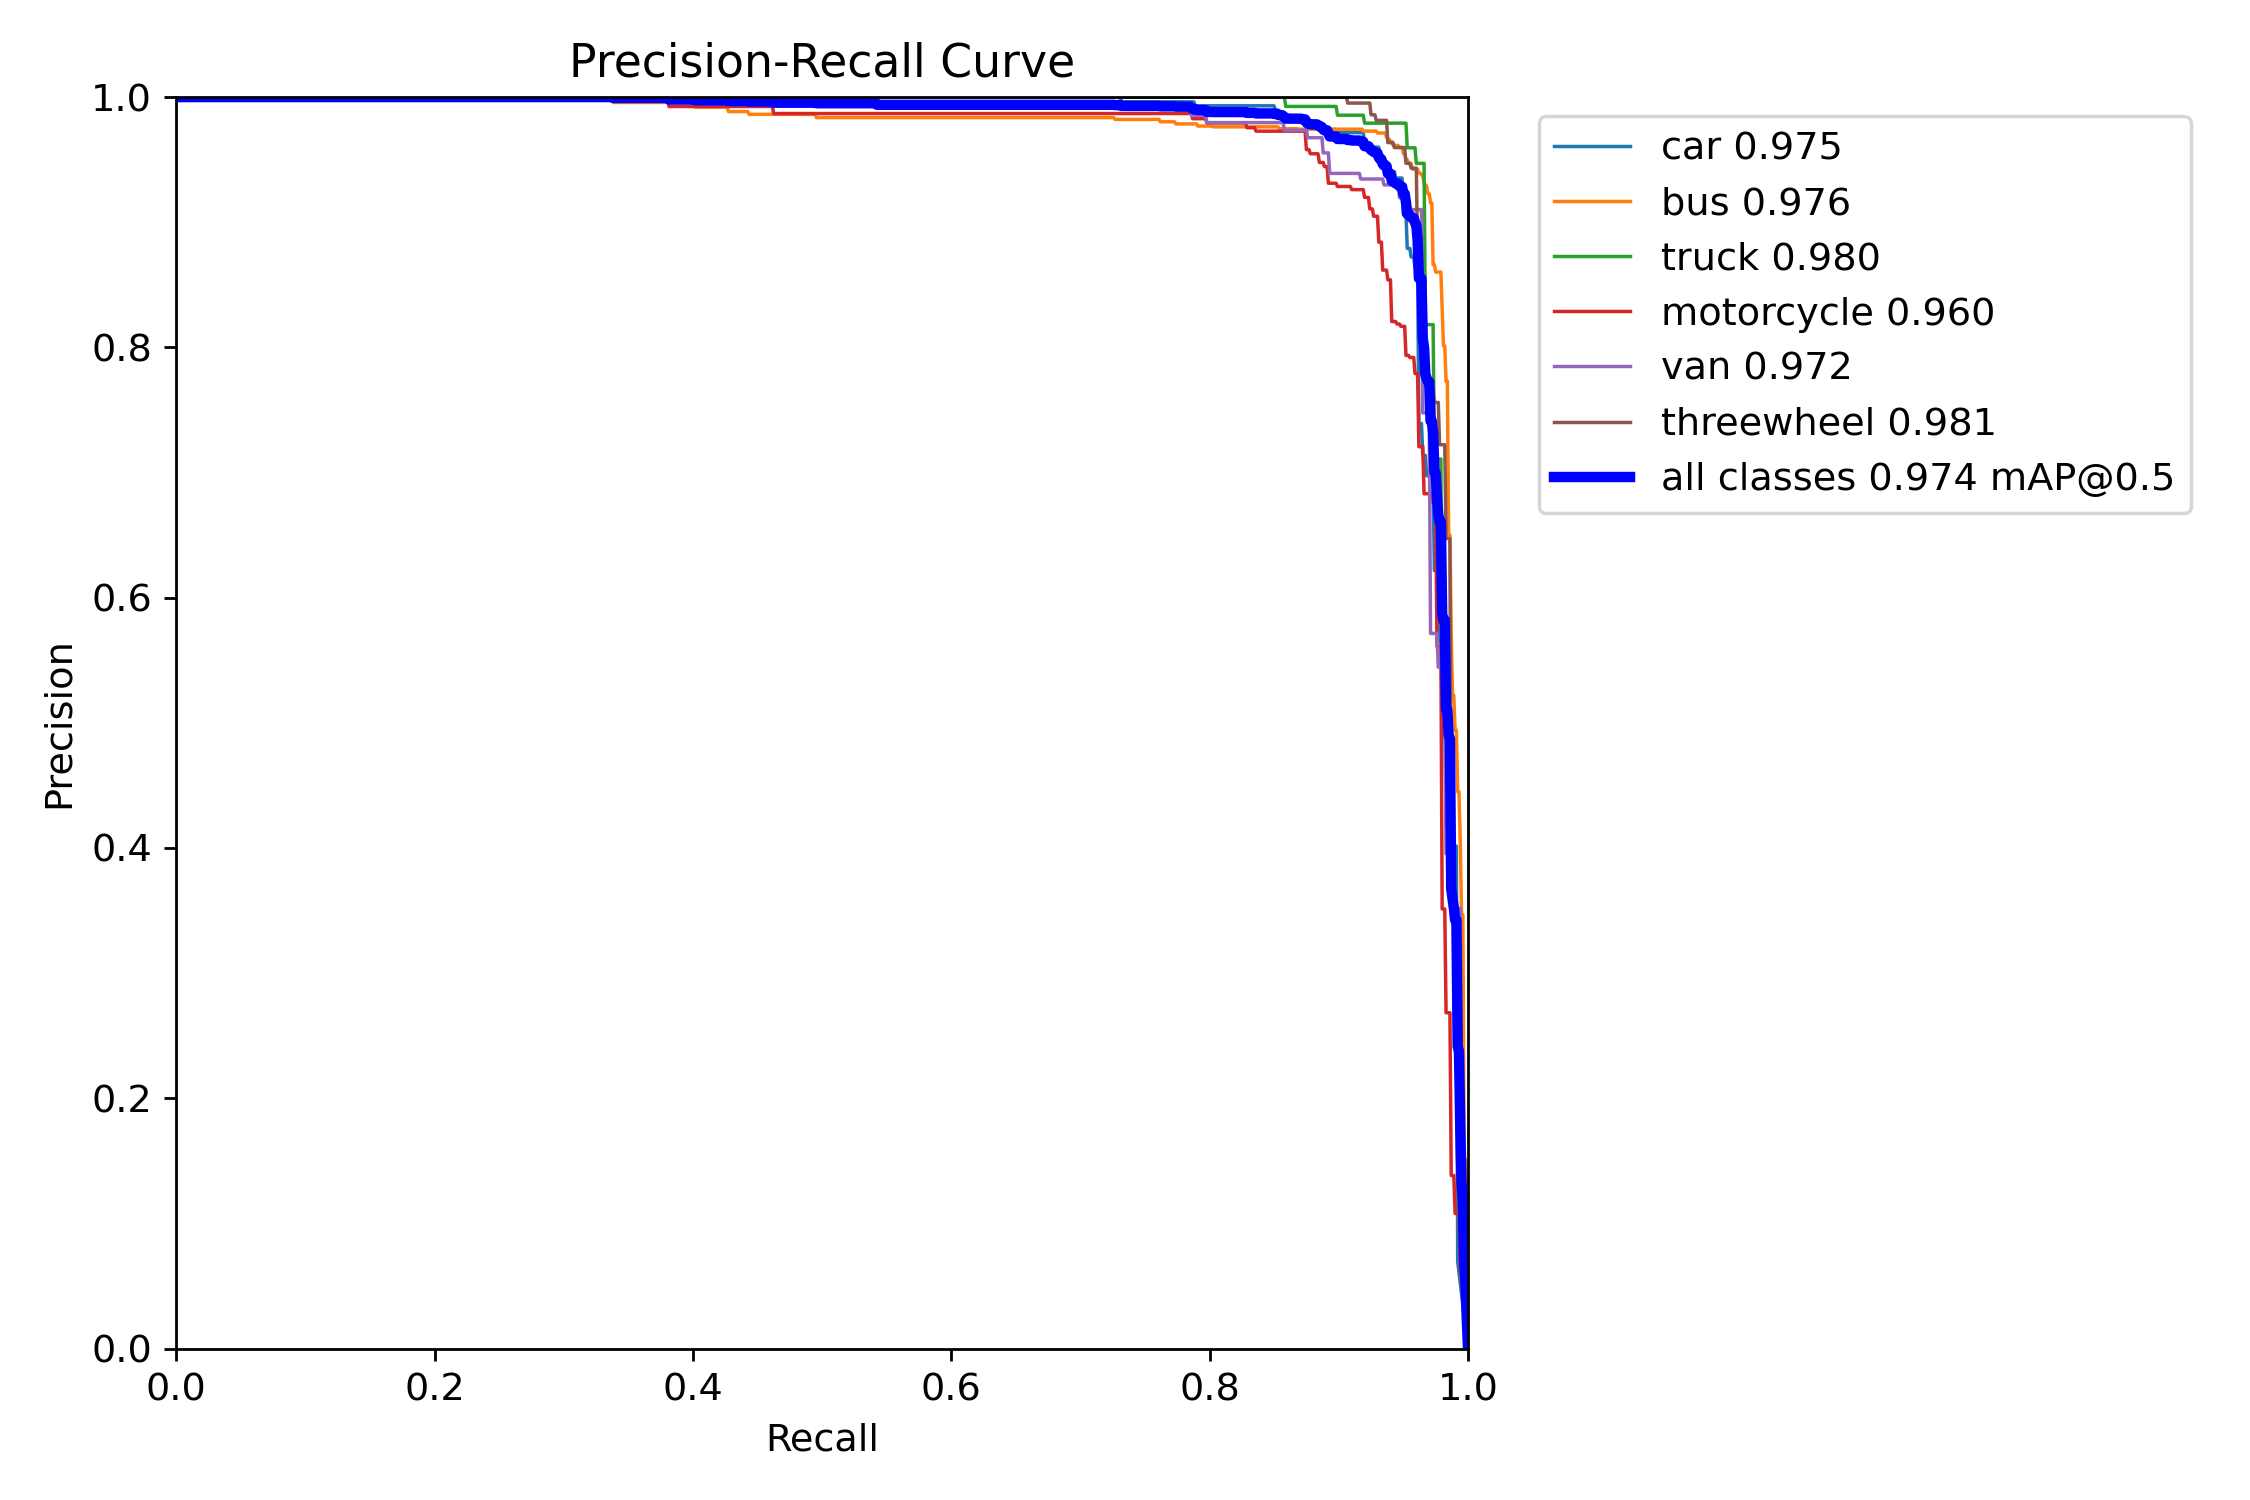


📉 F1 CURVE:


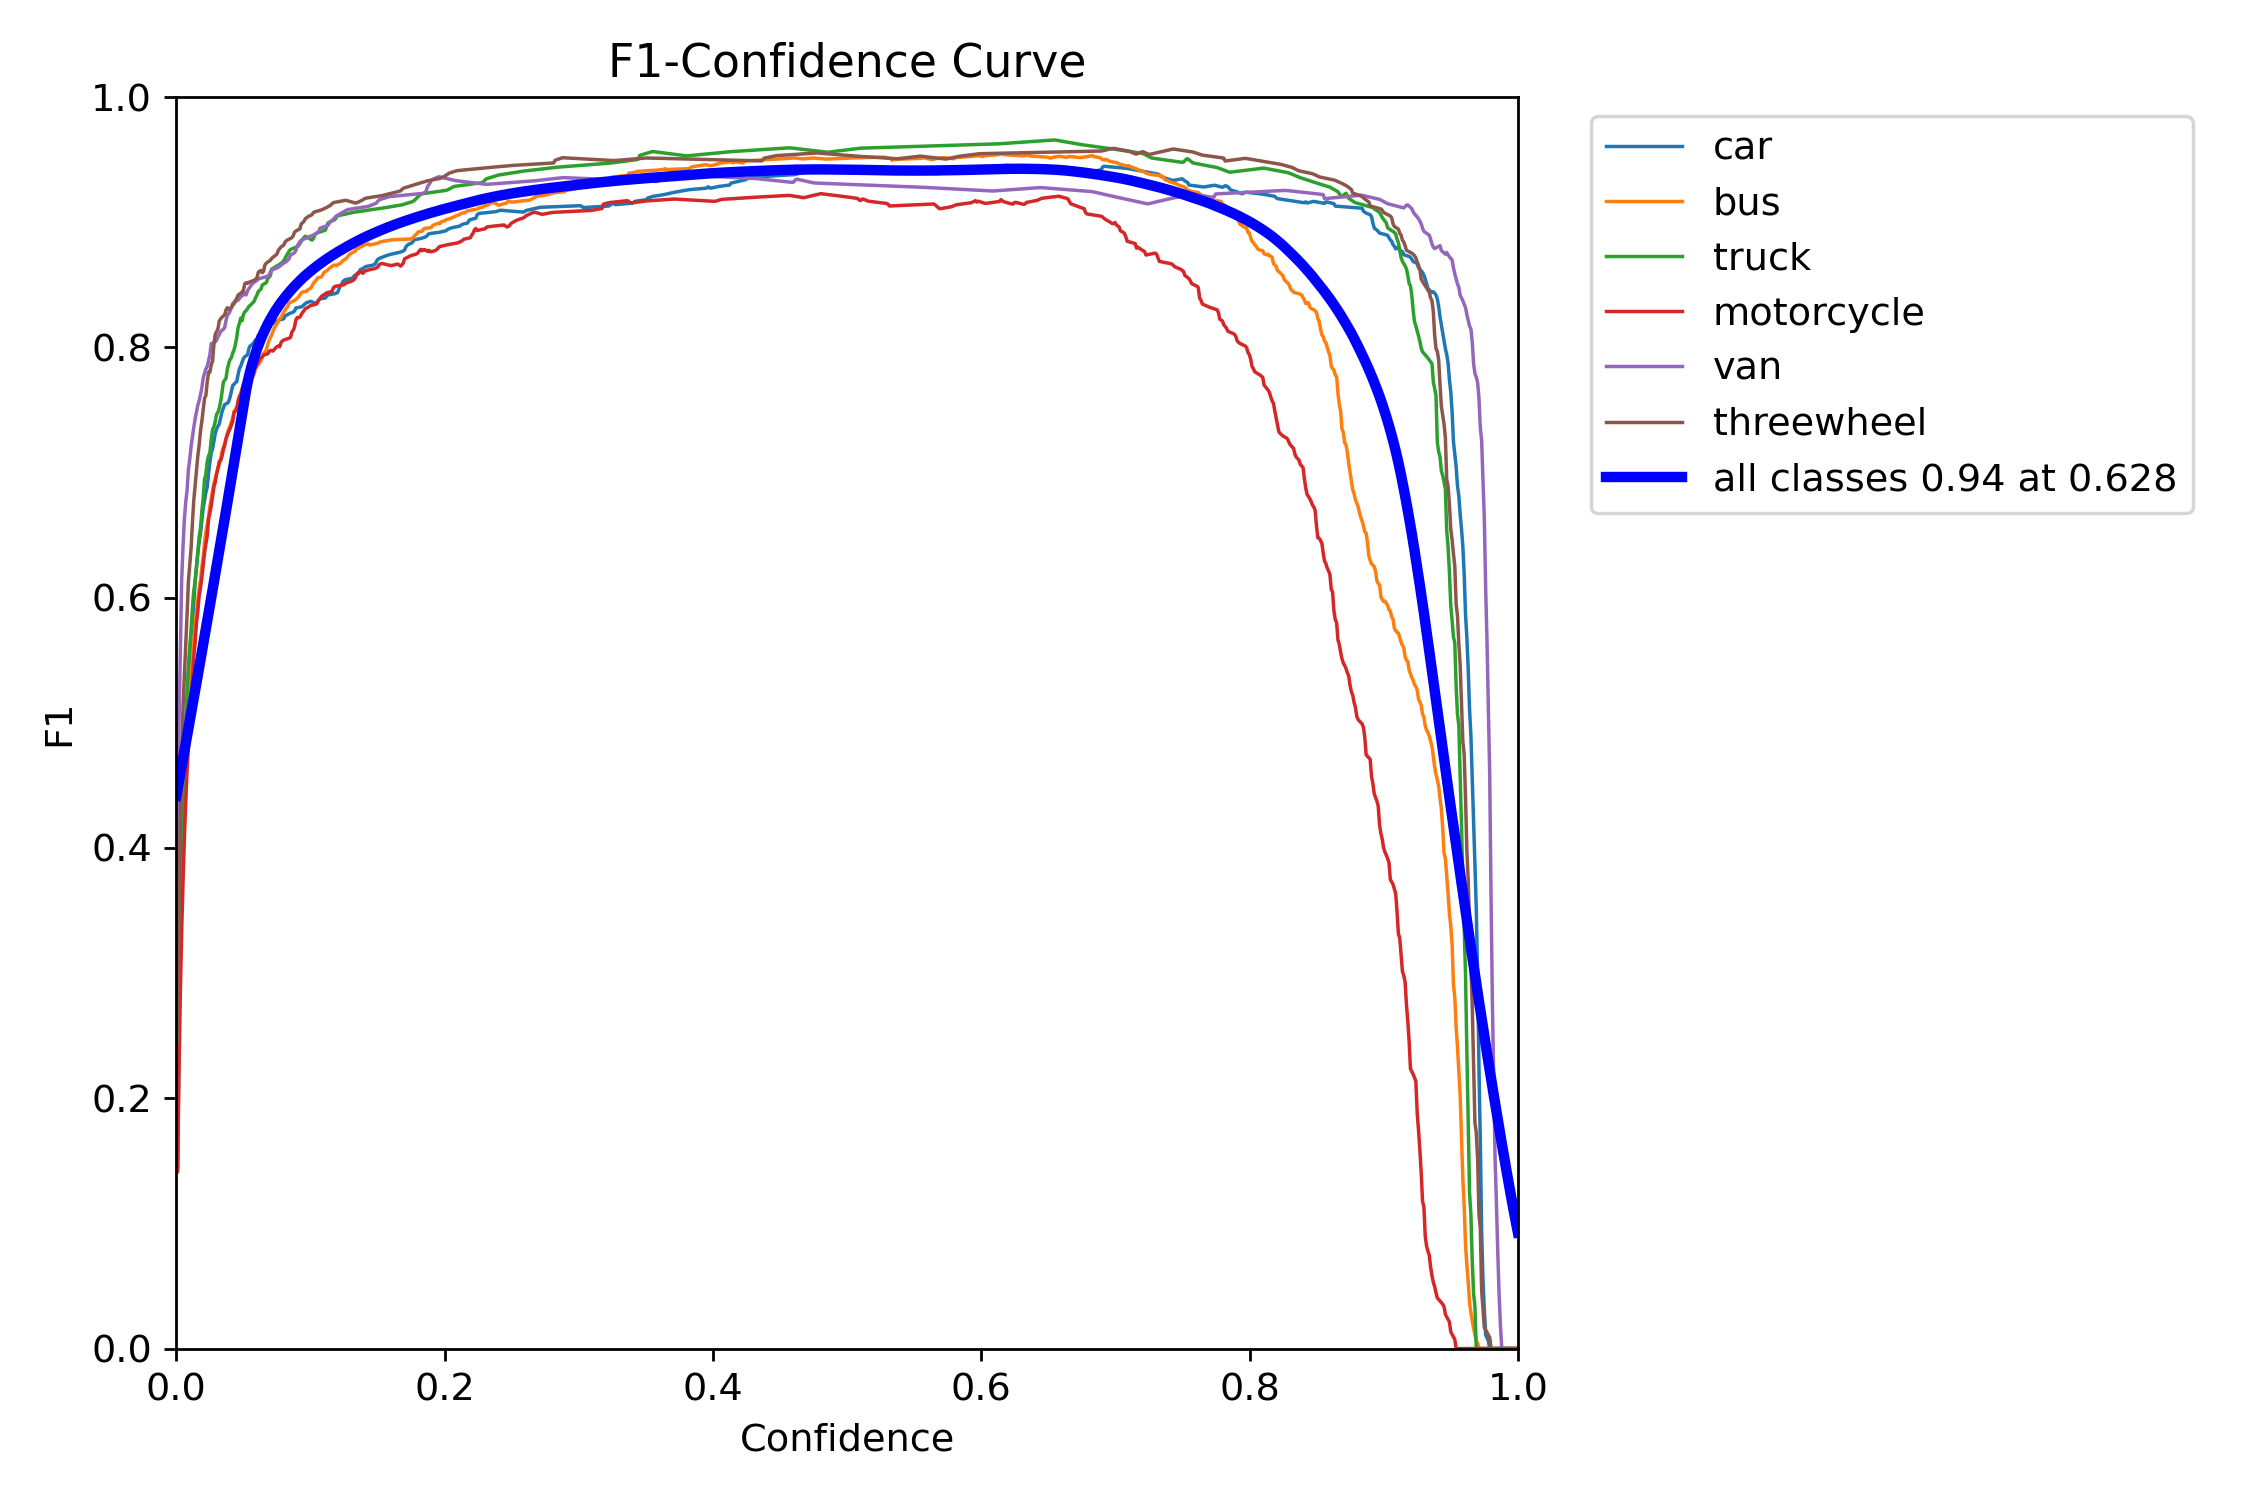

In [12]:
from IPython.display import display, Image

results_dir = '/kaggle/working/runs/detect/vehicle_project/final_model_v1'

# 1. Find and copy best.pt
best_model_path = f'{results_dir}/weights/best.pt'

if os.path.exists(best_model_path):
    print(f"FOUND MODEL AT: {best_model_path}")
    shutil.copy(best_model_path, '/kaggle/working/best.pt')
    print("Copied to /kaggle/working/best.pt (Download this file!)")
else:
    print("Could not find best.pt.")

# 2. Confusion Matrix
print("\n📊 CONFUSION MATRIX:")
display(Image(filename=f'{results_dir}/confusion_matrix_normalized.png', width=600))

# 3. Training Curves
print("\n📈 TRAINING CURVES:")
display(Image(filename=f'{results_dir}/results.png', width=800))

# 4. PR Curve
print("\n🎯 PRECISION-RECALL CURVE:")
display(Image(filename=f'{results_dir}/BoxPR_curve.png', width=700))

# 5. F1 Curve
print("\n📉 F1 CURVE:")
display(Image(filename=f'{results_dir}/BoxF1_curve.png', width=700))

Running inference on 5 sample images...

Results saved to /kaggle/working/test_predictions/samples
📸 modified1_image_73_jpg.rf.3eefa6c471d2eda2cd2d0002e4e5d07a.jpg


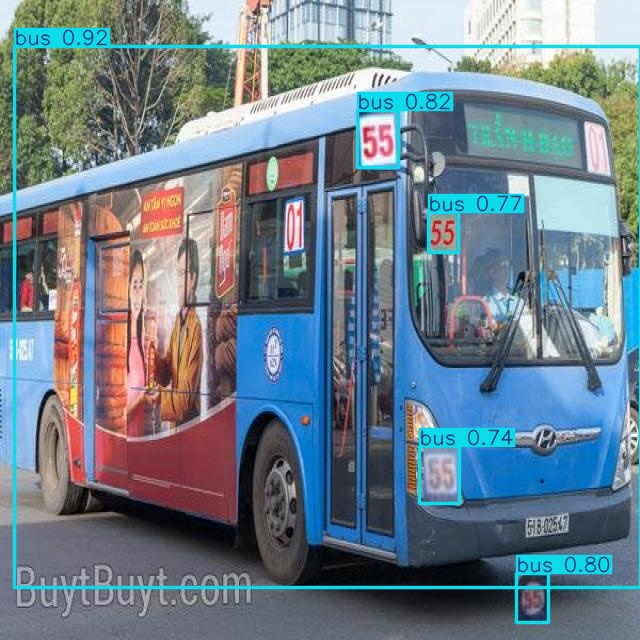


Results saved to /kaggle/working/test_predictions/samples
📸 modified1_img1_3_jpg.rf.086d788caac9c8203dacd575f805b257.jpg


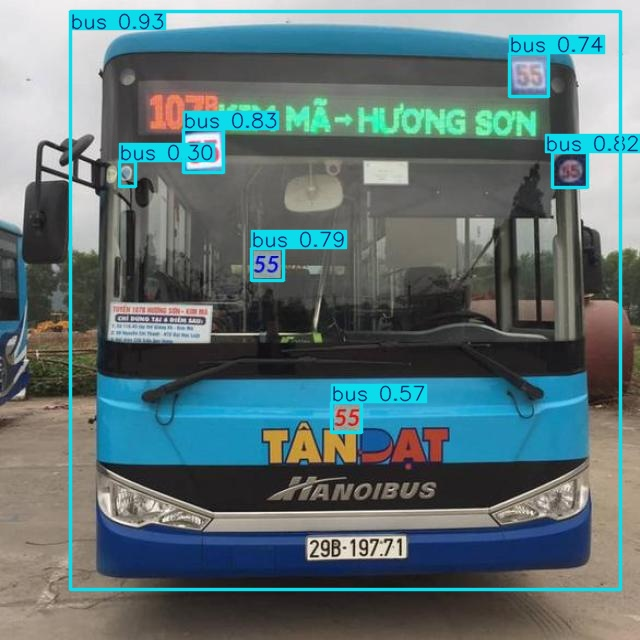


Results saved to /kaggle/working/test_predictions/samples
📸 1682252179231_jpg.rf.fe12c4e3c9bbf0eea6c6ccfae2c65427.jpg


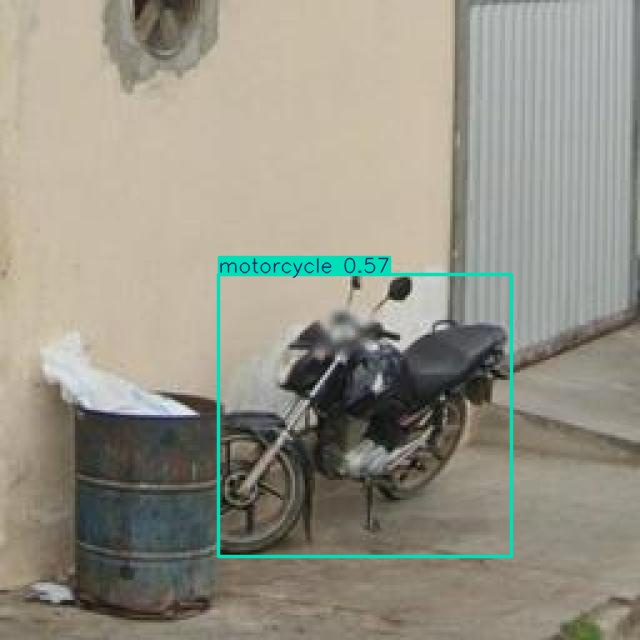


Results saved to /kaggle/working/test_predictions/samples
📸 modified_images-50-_jpeg.rf.4fa58a9c181236f7c6b326a37fcd2590.jpg


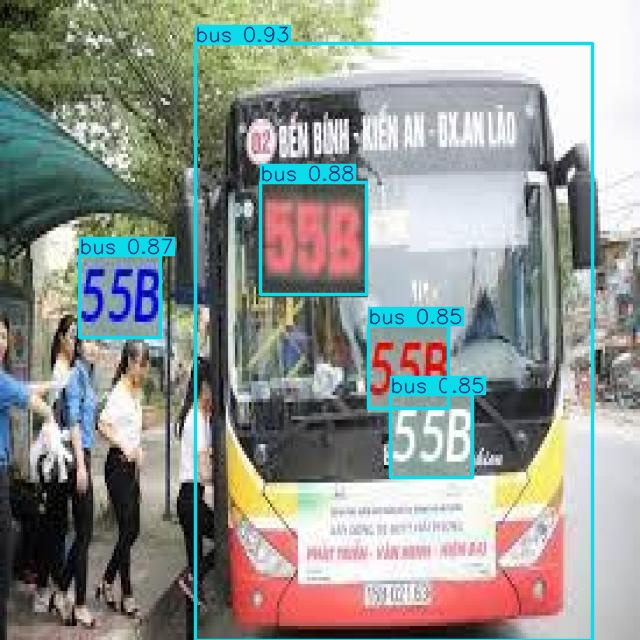


Results saved to /kaggle/working/test_predictions/samples
📸 1682252179149_jpg.rf.d8a9c06da08c23307de46995d0c6f8aa.jpg


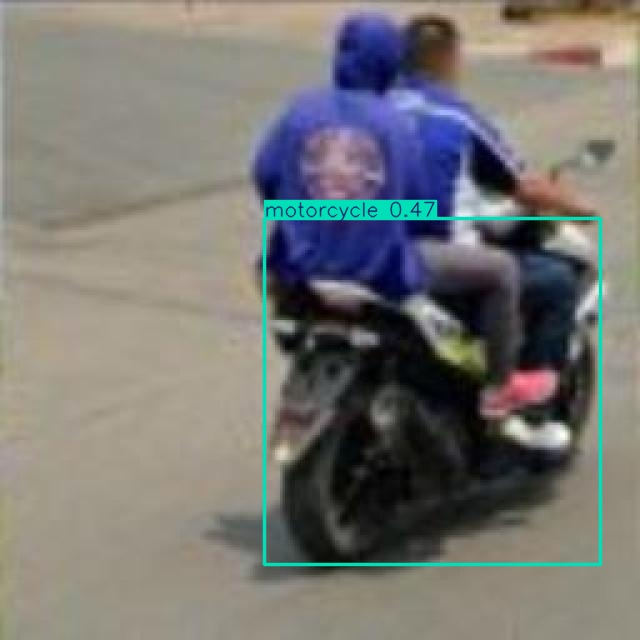

In [13]:
# 7. TEST ON SAMPLE IMAGES
from IPython.display import display, Image
import random

test_images = glob.glob(f"{WORKING_DIR}/test/images/*.jpg") + glob.glob(f"{WORKING_DIR}/test/images/*.png")

if not test_images:
    print("No test images found.")
else:
    sample_images = random.sample(test_images, min(5, len(test_images)))
    
    best_model_path = '/kaggle/working/runs/detect/vehicle_project/final_model_v1/weights/best.pt'
    test_model = YOLO(best_model_path)
    
    print(f"Running inference on {len(sample_images)} sample images...\n")
    
    for img_path in sample_images:
        results = test_model.predict(
            source=img_path,
            imgsz=640,
            conf=0.25,
            save=True,
            project='/kaggle/working/test_predictions',
            name='samples',
            exist_ok=True,
            verbose=False
        )
        
        # Display result
        pred_path = f"/kaggle/working/test_predictions/samples/{os.path.basename(img_path)}"
        if os.path.exists(pred_path):
            print(f"📸 {os.path.basename(img_path)}")
            display(Image(filename=pred_path, width=700))
            print()

In [14]:
# 8. FINAL PACKAGE (notebook + weights + predictions)
import zipfile

output_zip = '/kaggle/working/final_package.zip'

with zipfile.ZipFile(output_zip, 'w', zipfile.ZIP_DEFLATED) as zf:
    # best weights
    zf.write('/kaggle/working/best.pt', 'best.pt')
    
    # onnx model
    onnx_path = f'{results_dir}/weights/best.onnx'
    if os.path.exists(onnx_path):
        zf.write(onnx_path, 'best.onnx')
    
    # notebook — saves itself
    notebook_files = glob.glob('/kaggle/working/*.ipynb')
    for nb in notebook_files:
        zf.write(nb, os.path.basename(nb))
    
    # sample predictions
    pred_images = glob.glob('/kaggle/working/test_predictions/samples/*.jpg')
    for p in pred_images:
        zf.write(p, f'sample_predictions/{os.path.basename(p)}')

print(f"✅ Done! Download 'final_package.zip' from the Output tab on the right.")

✅ Done! Download 'final_package.zip' from the Output tab on the right.


In [18]:
# 9. COLLECT ALL OUTPUTS INTO ONE FOLDER
FINAL_DIR = '/kaggle/working/FINAL_OUTPUT'
os.makedirs(FINAL_DIR, exist_ok=True)

# Best weights
shutil.copy('/kaggle/working/runs/detect/vehicle_project/final_model_v1/weights/best.pt',
            f'{FINAL_DIR}/best.pt')
shutil.copy('/kaggle/working/runs/detect/vehicle_project/final_model_v1/weights/best.onnx',
            f'{FINAL_DIR}/best.onnx')

# Training plots
for png in glob.glob('/kaggle/working/runs/detect/vehicle_project/final_model_v1/*.png'):
    shutil.copy(png, f'{FINAL_DIR}/{os.path.basename(png)}')

# Sample predictions
os.makedirs(f'{FINAL_DIR}/sample_predictions', exist_ok=True)
for img in glob.glob('/kaggle/working/test_predictions/samples/*.jpg'):
    shutil.copy(img, f'{FINAL_DIR}/sample_predictions/{os.path.basename(img)}')

# Notebook
for nb in glob.glob('/kaggle/working/*.ipynb'):
    shutil.copy(nb, f'{FINAL_DIR}/{os.path.basename(nb)}')

print("✅ Everything is in FINAL_OUTPUT folder.")
print("\nContents:")
for f in sorted(os.listdir(FINAL_DIR)):
    print(f"   {f}")

✅ Everything is in FINAL_OUTPUT folder.

Contents:
   BoxF1_curve.png
   BoxPR_curve.png
   BoxP_curve.png
   BoxR_curve.png
   best.onnx
   best.pt
   confusion_matrix.png
   confusion_matrix_normalized.png
   results.png
   sample_predictions
